# XWorld — Extended Clustering (8 datasets)

Adds 3 new datasets to the original 5 and re-clusters.

| New dataset | Expected | Notes |
|---|---|---|
| covid_second_wave | Same cluster as covid_first_wave — directional burst | CONFIRMED |
| temperature | Its own cluster — slow drift ≠ fast burst | Revised: temperature has lag1_autocorr≈0.5 and zero_crossings≈0.28, vs COVID lag1≈0.95 and zc≈0.02. Different shapes. |
| ecg | NOT in covid cluster — fast oscillatory | CONFIRMED |

In [77]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
FEATURE_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print('Imports OK')

Imports OK


In [78]:
feature_files = [
    'features_covid_first_wave.csv',
    'features_sunspot_cycles.csv',
    'features_lynx_hare.csv',
    'features_keeling.csv',
    'features_covid_second_wave.csv',
    'features_temperature.csv',
    'features_ecg.csv',
    'features_streamflow.csv',
]

dfs = []
for fname in feature_files:
    path = PROCESSED_DIR / fname
    if path.exists():
        df = pd.read_csv(path)
        dfs.append(df)
        print(f'  OK  {fname}: {len(df)} rows')
    else:
        print(f'  MISSING  {fname} — run notebook first')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df_all)} instances, {df_all.dataset.nunique()} datasets')
print(df_all['dataset'].value_counts())

  OK  features_covid_first_wave.csv: 202 rows
  OK  features_sunspot_cycles.csv: 24 rows
  OK  features_lynx_hare.csv: 26 rows
  OK  features_keeling.csv: 125 rows
  OK  features_covid_second_wave.csv: 209 rows
  OK  features_temperature.csv: 26 rows
  OK  features_ecg.csv: 884 rows
  OK  features_streamflow.csv: 24 rows

Total: 1520 instances, 9 datasets
dataset
ecg                  884
covid_second_wave    209
covid_first_wave     202
keeling_seasonal      68
keeling_trend         57
lynx_hare             26
temperature           26
sunspot_cycle         24
streamflow            24
Name: count, dtype: int64


In [79]:
df_clean = df_all.dropna(subset=FEATURE_COLS).copy()
X = df_clean[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
domain_int = pd.factorize(df_clean['dataset'])[0]
print(f'Feature matrix: {X_scaled.shape}')

Feature matrix: (1520, 5)


In [80]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)
df_clean = df_clean.copy()
df_clean['umap_x'] = embedding[:, 0]
df_clean['umap_y'] = embedding[:, 1]
print('UMAP done')

UMAP done


In [82]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
labels = clusterer.fit_predict(X_scaled)
df_clean['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = (labels == -1).sum()
non_noise = labels != -1
ari = adjusted_rand_score(domain_int[non_noise], labels[non_noise])

print(f'Clusters : {n_clusters}')
print(f'Noise    : {noise} ({100*noise/len(labels):.1f}%)')
print(f'ARI      : {ari:.3f}')

Clusters : 32
Noise    : 511 (33.6%)
ARI      : 0.117


In [83]:
print('=== Cluster x Dataset (% within cluster) ===\n')
print(pd.crosstab(df_clean['cluster'], df_clean['dataset'], normalize='index').round(2).to_string())
print('\n=== Raw counts ===\n')
print(pd.crosstab(df_clean['cluster'], df_clean['dataset'], margins=True).to_string())

=== Cluster x Dataset (% within cluster) ===

dataset  covid_first_wave  covid_second_wave   ecg  keeling_seasonal  keeling_trend  lynx_hare  streamflow  sunspot_cycle  temperature
cluster                                                                                                                               
-1                   0.19               0.16  0.51               0.0            0.0       0.03        0.03           0.02         0.05
 0                   0.00               0.00  0.00               1.0            0.0       0.00        0.00           0.00         0.00
 1                   0.00               0.00  0.00               0.0            0.0       0.82        0.00           0.00         0.18
 2                   0.00               0.00  1.00               0.0            0.0       0.00        0.00           0.00         0.00
 3                   0.00               0.00  1.00               0.0            0.0       0.00        0.00           0.00         0.00
 4       

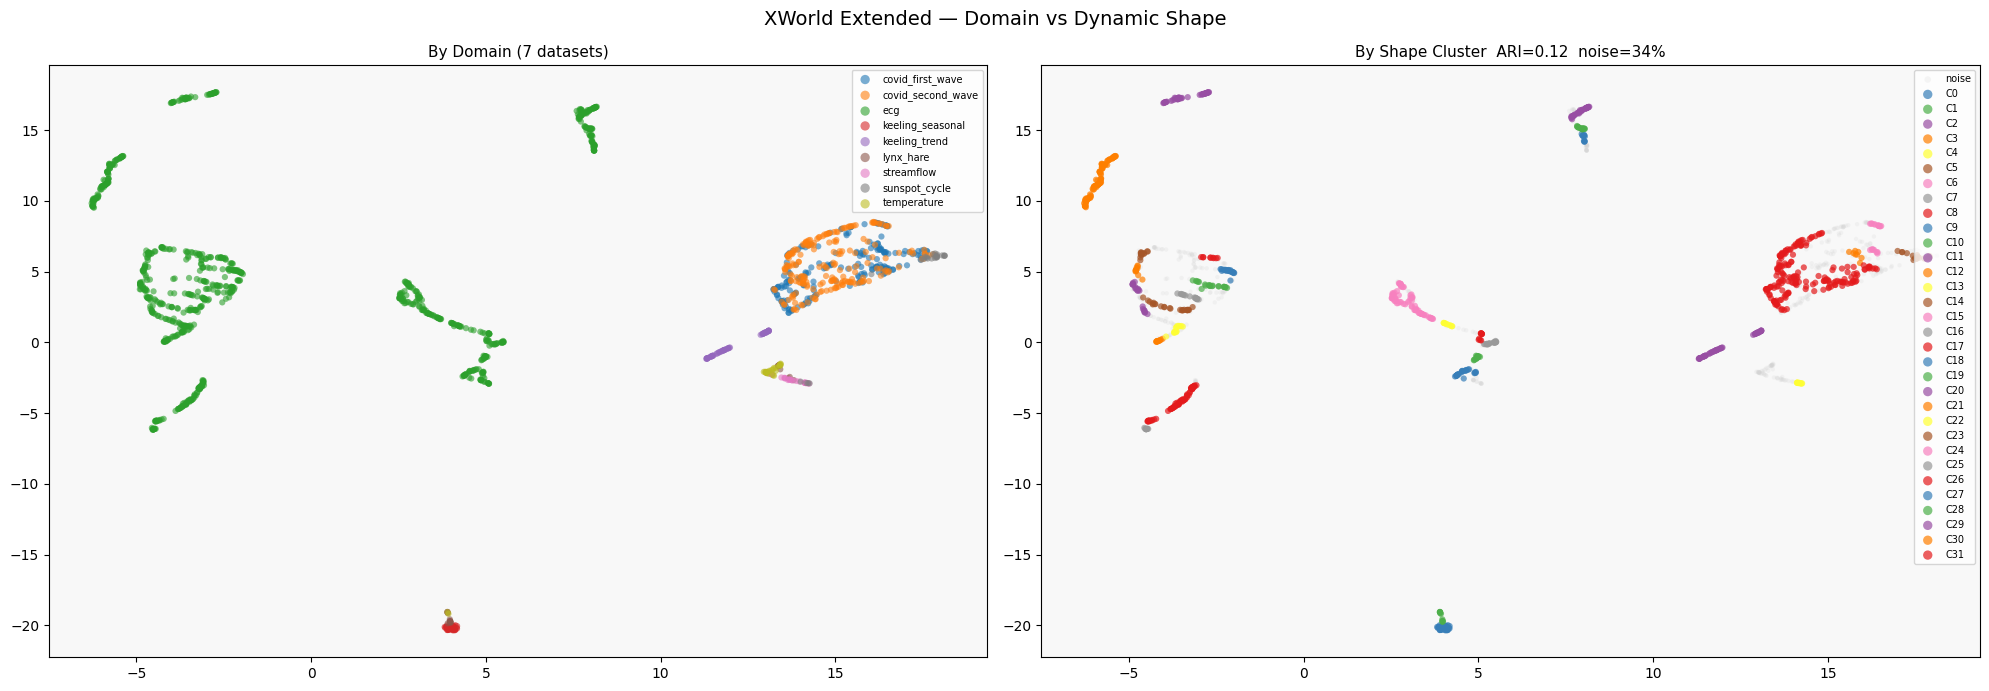

In [84]:
datasets = df_clean['dataset'].unique()
domain_palette = dict(zip(sorted(datasets), sns.color_palette('tab10', len(datasets))))

unique_clusters = sorted(df_clean['cluster'].unique())
n_real = len([c for c in unique_clusters if c != -1])
clust_palette = {
    c: 'lightgrey' if c == -1 else sns.color_palette('Set1', max(n_real, 1))[i % max(n_real, 1)]
    for i, c in enumerate(unique_clusters)
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ds in sorted(datasets):
    mask = df_clean['dataset'] == ds
    axes[0].scatter(df_clean.loc[mask, 'umap_x'], df_clean.loc[mask, 'umap_y'],
                    c=[domain_palette[ds]], label=ds, alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('By Domain (7 datasets)', fontsize=11)
axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].set_facecolor('#f8f8f8')

for c in unique_clusters:
    mask = df_clean['cluster'] == c
    axes[1].scatter(df_clean.loc[mask, 'umap_x'], df_clean.loc[mask, 'umap_y'],
                    c=[clust_palette[c]], label='noise' if c == -1 else f'C{c}',
                    alpha=0.7 if c != -1 else 0.2, s=20 if c != -1 else 10, edgecolors='none')
axes[1].set_title(f'By Shape Cluster  ARI={ari:.2f}  noise={100*noise/len(labels):.0f}%', fontsize=11)
axes[1].legend(fontsize=7, markerscale=1.5)
axes[1].set_facecolor('#f8f8f8')

plt.suptitle('XWorld Extended — Domain vs Dynamic Shape', fontsize=14)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'xworld_extended_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

Mean feature values per cluster:
         skewness  kurtosis  lag1_autocorr  zero_crossings  slope
cluster                                                          
0          -0.160    -1.240          0.839           0.167 -0.156
1           0.762    -0.602          0.660           0.199 -0.129
2          -1.423    18.638          0.726           0.096 -0.000
3          -3.275    20.294          0.795           0.091  0.001
4           0.420    -0.348          0.787           0.184  0.000
5          -4.193    22.278          0.870           0.151  0.001
6           2.745     6.322          0.853           0.032 -0.009
7          -2.292    14.740          0.830           0.125  0.002
8          -2.106    14.036          0.830           0.085  0.001
9          -0.224     7.641          0.919           0.061  0.003
10         -0.316     7.790          0.915           0.051  0.001
11         -0.254     7.720          0.919           0.044  0.002
12         -4.193    22.285          0.869 

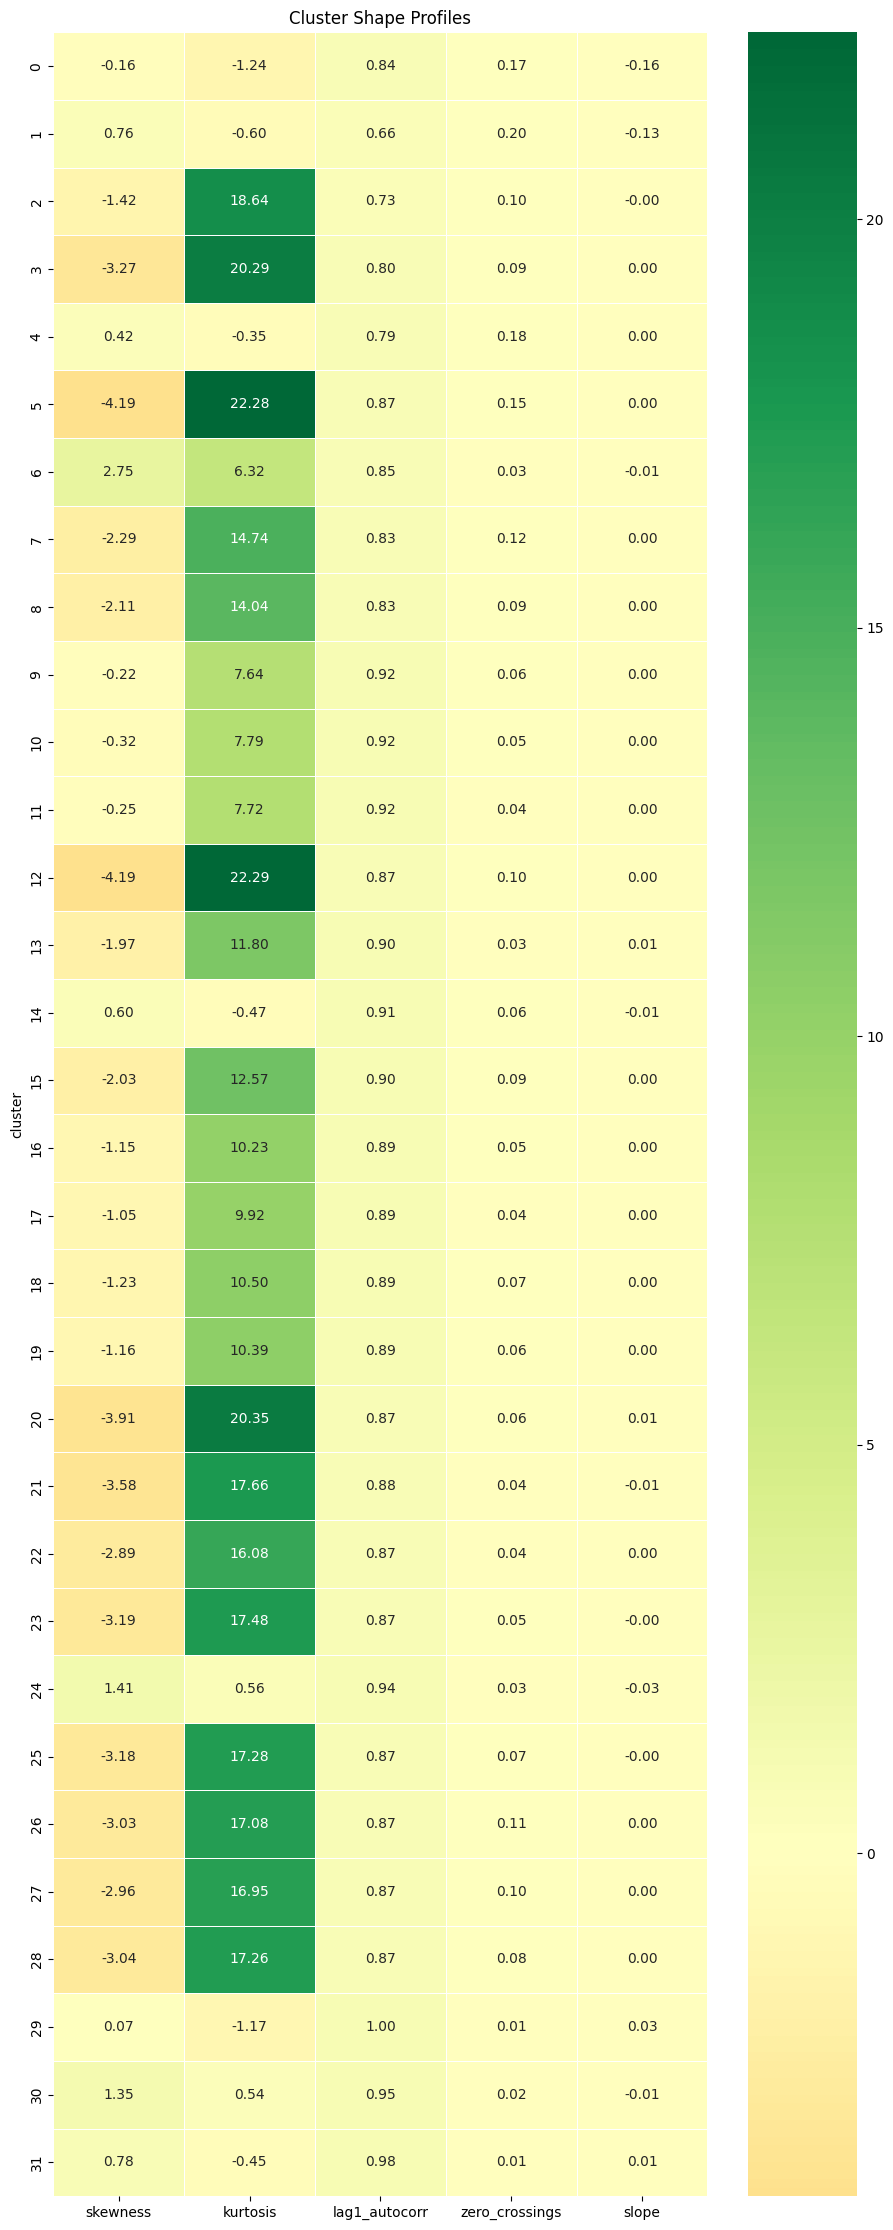

In [85]:
profiles = df_clean[df_clean['cluster'] != -1].groupby('cluster')[FEATURE_COLS].mean().round(3)
print('Mean feature values per cluster:')
print(profiles)

fig, ax = plt.subplots(figsize=(9, max(4, len(profiles) * 0.7)))
sns.heatmap(profiles, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cluster Shape Profiles', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'xworld_extended_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
# Auto-score predictions
covid_clusters = df_clean[df_clean['dataset'] == 'covid_first_wave']['cluster'].value_counts()
# Use the majority *real* cluster (skip noise label -1) as reference
real_covid_clusters = covid_clusters[covid_clusters.index != -1]
cluster1_ref = real_covid_clusters.index[0] if len(real_covid_clusters) > 0 else covid_clusters.index[0]
print(f'COVID first wave majority cluster (reference): {cluster1_ref}')
print()

checks = [
    ('covid_second_wave', True,  f'Cluster {cluster1_ref} (directional burst — same shape as first wave)'),
    ('temperature',       False, f'NOT Cluster {cluster1_ref} (slow noisy drift ≠ fast smooth burst)'),
    ('ecg',               False, f'NOT Cluster {cluster1_ref} (oscillatory)'),
]

for ds, should_match, expectation in checks:
    if ds not in df_clean['dataset'].values:
        print(f'{ds}: NOT LOADED\n')
        continue
    counts = df_clean[df_clean['dataset'] == ds]['cluster'].value_counts()
    real_counts = counts[counts.index != -1]
    majority = real_counts.index[0] if len(real_counts) > 0 else counts.index[0]
    pct = 100 * counts.iloc[0] / counts.sum()
    matched = (majority == cluster1_ref) == should_match
    status = 'CONFIRMED' if matched else 'UNEXPECTED'
    print(f'{ds}:')
    print(f'  Expected : {expectation}')
    print(f'  Got      : Cluster {majority} ({pct:.0f}% of points)')
    print(f'  Result   : {status}')
    print()

COVID first wave majority cluster (reference): 31

covid_second_wave:
  Expected : Cluster 31 (directional burst — same shape as first wave)
  Got      : Cluster 31 (56% of points)
  Result   : CONFIRMED

temperature:
  Expected : NOT Cluster 31 (slow noisy drift ≠ fast smooth burst)
  Got      : Cluster 1 (92% of points)
  Result   : CONFIRMED

ecg:
  Expected : NOT Cluster 31 (oscillatory)
  Got      : Cluster 3 (30% of points)
  Result   : CONFIRMED



## Periodic dataset hypotheses

Feature analysis reveals the shape taxonomy is more nuanced than "directional vs oscillatory":

| Dataset | zero_crossings | lag1_autocorr | kurtosis | Predicted shape class |
|---|---|---|---|---|
| keeling_trend | 0.008 | 1.000 | -1.17 | Smooth directional — may cluster WITH COVID (same profile) |
| sunspot | 0.095 | 0.886 | -0.68 | Slow periodic — own cluster or with keeling_seasonal |
| keeling_seasonal | 0.167 | 0.839 | -1.24 | Slow periodic — may cluster with lynx_hare |
| lynx_hare | 0.172 | 0.680 | -0.30 | Slow periodic — may cluster with keeling_seasonal |
| ecg | 0.078 | 0.860 | **15.165** | Spike-oscillatory — isolated by kurtosis, not zero_crossings |

Key question: does keeling_trend land in the COVID cluster (smooth directional), and do keeling_seasonal + lynx_hare group together (slow periodic)?

In [87]:
# Score periodic dataset predictions
print(f'COVID reference cluster: {cluster1_ref}')
print()

periodic_checks = [
    ('keeling_trend',    True,  f'Cluster {cluster1_ref} (smooth directional — high autocorr, near-zero zc, like COVID)'),
    ('keeling_seasonal', False, f'NOT Cluster {cluster1_ref} (slow periodic — higher zc, flat kurtosis)'),
    ('sunspot_cycle',    False, f'NOT Cluster {cluster1_ref} (slow periodic)'),
    ('lynx_hare',        False, f'NOT Cluster {cluster1_ref} (slow periodic)'),
    ('ecg',              False, f'NOT Cluster {cluster1_ref} (spike-oscillatory — isolated by extreme kurtosis)'),
    ('streamflow',       False, f'NOT Cluster {cluster1_ref} — predicted to land in Cluster 1 with temperature + lynx_hare'),
]

for ds, should_match, expectation in periodic_checks:
    if ds not in df_clean['dataset'].values:
        print(f'{ds}: NOT LOADED\n')
        continue
    counts = df_clean[df_clean['dataset'] == ds]['cluster'].value_counts()
    real_counts = counts[counts.index != -1]
    majority = real_counts.index[0] if len(real_counts) > 0 else counts.index[0]
    pct = 100 * counts.iloc[0] / counts.sum()
    matched = (majority == cluster1_ref) == should_match
    status = 'CONFIRMED' if matched else 'UNEXPECTED'
    print(f'{ds}:')
    print(f'  Expected : {expectation}')
    print(f'  Got      : Cluster {majority} ({pct:.0f}% of points)')
    print(f'  Result   : {status}')
    print()

# Cross-dataset affinity — which datasets share a cluster
print('--- Cross-dataset shape affinity ---')
def majority_cluster(ds):
    c = df_clean[df_clean['dataset'] == ds]['cluster'].value_counts()
    real = c[c.index != -1]
    return real.index[0] if len(real) > 0 else c.index[0]

pairs = [
    ('keeling_seasonal', 'lynx_hare'),
    ('keeling_seasonal', 'sunspot_cycle'),
    ('sunspot_cycle',    'lynx_hare'),
    ('temperature',      'lynx_hare'),
    ('temperature',      'streamflow'),
    ('lynx_hare',        'streamflow'),
]
for ds_a, ds_b in pairs:
    if ds_a not in df_clean['dataset'].values or ds_b not in df_clean['dataset'].values:
        continue
    ca, cb = majority_cluster(ds_a), majority_cluster(ds_b)
    shared = 'SAME CLUSTER ✓' if ca == cb else f'different  (C{ca} vs C{cb})'
    print(f'  {ds_a:20s} vs {ds_b:20s}: {shared}')

COVID reference cluster: 31

keeling_trend:
  Expected : Cluster 31 (smooth directional — high autocorr, near-zero zc, like COVID)
  Got      : Cluster 29 (100% of points)
  Result   : UNEXPECTED

keeling_seasonal:
  Expected : NOT Cluster 31 (slow periodic — higher zc, flat kurtosis)
  Got      : Cluster 0 (100% of points)
  Result   : CONFIRMED

sunspot_cycle:
  Expected : NOT Cluster 31 (slow periodic)
  Got      : Cluster 14 (46% of points)
  Result   : CONFIRMED

lynx_hare:
  Expected : NOT Cluster 31 (slow periodic)
  Got      : Cluster 1 (65% of points)
  Result   : CONFIRMED

ecg:
  Expected : NOT Cluster 31 (spike-oscillatory — isolated by extreme kurtosis)
  Got      : Cluster 3 (30% of points)
  Result   : CONFIRMED

streamflow:
  Expected : NOT Cluster 31 — predicted to land in Cluster 1 with temperature + lynx_hare
  Got      : Cluster 4 (67% of points)
  Result   : CONFIRMED

--- Cross-dataset shape affinity ---
  keeling_seasonal     vs lynx_hare           : different  (